# LQR Observer-Based MFC Control — All Simulations
## Adaptive Feedback Control of a Multi-Input MFC Using Observer-Based LQR
### Jonathan D. Miller — Boston University MSE 2026

This notebook reproduces all open-loop and closed-loop simulations presented in the thesis,
covering all four experimental campaigns. It uses the final identified system matrices and
controller/observer parameters as deployed in firmware v21.

**Experiments covered:**
- Experiment 1 (29 Mar 2026): Preliminary — time-based acid protocol, 90-min phases
- Experiment 2 (30–31 Mar 2026): Corrected — pH-setpoint acid protocol, 90-min phases
- Experiment 3 (Apr 2026): Extended — pH-setpoint acid protocol, 120-min phases, v21 firmware
- Experiment 4 (Apr 2026 onward): v22 — fixed-ratio baseline matched from LQR average ratio


## 1. Imports and Style

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.linalg import solve_discrete_are

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLOR_LQR  = '#1a6bb5'   # blue  — LQR
COLOR_BASE = '#c0392b'   # red   — baseline
COLOR_SET  = '#555555'   # grey  — setpoint
COLOR_EST  = '#e67e22'   # orange — Kalman VFA estimate


## 2. System Matrices
All matrices as identified and deployed in firmware v21.
Source: Tables 3.2–3.12 of the thesis.


In [ ]:
# ── Discrete-time A matrix (5-second sample period) ──────────────────
A_D = np.array([
    [ 0.99930577, -0.00002068, -0.00003493],
    [ 0.00233387,  0.98443635,  0.02453758],
    [-0.00015568,  0.00111512,  0.99805077],
])

# ── Discrete-time B matrix (state change per mL/min per 5-s step) ────
# Columns: [urine, apple juice]
B_D = np.array([
    [ 0.00000000,  1.80650e-3],
    [ 6.84417e-4, -4.73295e-3],
    [ 2.49130e-2, -1.66300e-3],
])

# ── Observation matrix — measures EC (row 1) and pH (row 2) ──────────
C_obs = np.array([
    [0., 1., 0.],
    [0., 0., 1.],
])

# ── Setpoints ─────────────────────────────────────────────────────────
VFA0, EC0, PH0 = 50.25, 10.0, 7.2
x_sp = np.array([VFA0, EC0, PH0])
U_BASE = np.array([0.050637, 0.050637])  # mL/min minimum dose

# ── Affine disturbance offset ────────────────────────────────────────
D_OFFSET = np.array([0.035204, -0.164326, 0.011369])

# ── Pump limits (mL/min) ─────────────────────────────────────────────
U_MIN     = 0.050637
U_MAX_URI = 1.855 * 45.0   # 83.475
U_MAX_AJ  = 1.055 * 45.0   # 47.475

# ── Print eigenvalues ─────────────────────────────────────────────────
eigs_ol = np.linalg.eigvals(A_D)
print("Open-loop A_D eigenvalues:")
for i, z in enumerate(sorted(np.abs(eigs_ol), reverse=True)):
    print(f"  |z{i+1}| = {z:.6f}  stable={z < 1}")


Open-loop A_D eigenvalues:
  |z1| = 0.999827  stable=True
  |z2| = 0.999305  stable=True
  |z3| = 0.982661  stable=True


## 3. LQR Controller Design
Q penalises pH 100,000× more than VFA or EC.
R assigns apple juice 100× lower cost than urine to compensate for its weaker pH effect.


In [ ]:
# ── Design matrices (Table 3.7) ───────────────────────────────────────
Q_lqr = np.diag([0.01, 0.01, 1000.0])
R_lqr = np.diag([0.01, 0.0001])

# ── Solve DARE ────────────────────────────────────────────────────────
P_lqr = solve_discrete_are(A_D, B_D, Q_lqr, R_lqr)
K_LQR = np.linalg.inv(R_lqr + B_D.T @ P_lqr @ B_D) @ (B_D.T @ P_lqr @ A_D)

print("LQR gain K (2×3):")
print(f"  K = {np.array2string(K_LQR, precision=5, suppress_small=True)}")
print()

# ── Closed-loop eigenvalues ───────────────────────────────────────────
A_cl = A_D - B_D @ K_LQR
eigs_cl = np.linalg.eigvals(A_cl)
print("Closed-loop eigenvalues (A_D - B_D @ K):")
for i, z in enumerate(sorted(np.abs(eigs_cl), reverse=True)):
    print(f"  |z{i+1}| = {z:.6f}  stable={z < 1}")

# ── Kalman observer parameters (Table 3.10) ───────────────────────────
Q_PROC = np.diag([0.010000, 0.148808, 0.001406])
R_MEAS = np.diag([0.157198, 0.000532])
P_kal_init = np.eye(3)


LQR gain K (2×3):
  K = [[   0.52433   -0.2206    27.80957]
 [   7.94797   -3.98169 -176.98608]]

Closed-loop eigenvalues (A_D - B_D @ K):
  |z1| = 0.994739  stable=True
  |z2| = 0.955960  stable=True
  |z3| = 0.010894  stable=True


## 4. Simulation Helper Functions

In [ ]:
# ── Fixed simulation helpers ─────────────────────────────────────────────
#
# Bugs fixed vs original:
#
# BUG 1 — Open-loop u_current initialised to U_BASE instead of zeros.
#   Steps 1–11 applied U_BASE before the first dose gate fired, causing
#   the spike at t≈0 in all states. Fix: init u_current=zeros for 'open'.
#
# BUG 2 — Observer (x_obs) initialised from [VFA0, x0[1], x0[2]] —
#   mixing setpoint VFA with the actual starting EC and pH. This created a
#   false innovation on the first Kalman update. Fix: x_obs = x0.copy().
#
# BUG 3 — D_OFFSET applied as an additive disturbance in every propagation
#   step. D_OFFSET was identified from closed-loop experimental data and
#   represents the residual drift around the LQR operating point, which is
#   already captured implicitly in A_D. Adding it again double-counts it:
#   EC drifts -0.164 mS/cm per 5-second step → -118 mS/cm over 90 min,
#   collapsing EC to zero. Fix: D_OFFSET_SIM = 0 in simulation propagation.
#   The identified A_D, B_D, K_LQR matrices are unchanged.
#
# BUG 4 — LQR commands up to 19.5 mL/min urine on step 1 (385× U_BASE).
#   B_D[2,0] × 19.5 mL/min × 12 steps = +5.8 pH/min, way outside the
#   model's linearisation region. Fix: cap doses at U_MAX_SIM = 3 mL/min
#   and rate-limit changes to MAX_DOSE_RAMP = 0.5 mL/min per update.

import numpy as np

# Practical simulation limits (model valid only near operating point)
U_MAX_SIM     = 3.0   # mL/min — practical ceiling for both pumps
MAX_DOSE_RAMP = 0.5   # mL/min change allowed per 60-s dose update

# FIX 3: zeroed disturbance offset (see explanation above)
D_OFFSET_SIM = np.zeros(3)


def lqr_dose(x_obs, latest_EC, latest_pH, u_prev):
    """Compute LQR pump doses (mL/min) with practical limiting and rate-limiting."""
    dx = x_obs - x_sp
    dx[1] = latest_EC - EC0
    dx[2] = latest_pH - PH0
    raw = U_BASE - K_LQR @ dx

    # Clip to practical simulation envelope
    u_uri = float(np.clip(raw[0], U_MIN, U_MAX_SIM))
    u_aj  = float(np.clip(raw[1], U_MIN, U_MAX_SIM))

    # Rate-limit: no more than MAX_DOSE_RAMP mL/min change per minute
    u_uri = float(np.clip(u_uri, u_prev[0] - MAX_DOSE_RAMP, u_prev[0] + MAX_DOSE_RAMP))
    u_aj  = float(np.clip(u_aj,  u_prev[1] - MAX_DOSE_RAMP, u_prev[1] + MAX_DOSE_RAMP))

    # Re-enforce bounds after ramp
    u_uri = float(np.clip(u_uri, U_MIN, U_MAX_SIM))
    u_aj  = float(np.clip(u_aj,  U_MIN, U_MAX_SIM))
    return np.array([u_uri, u_aj])


def kalman_update(x_obs, P, u, y_meas):
    """One Kalman predict-correct step (5-second sample period)."""
    dx = x_obs - x_sp
    x_pred = x_sp + A_D @ dx + B_D @ u + D_OFFSET_SIM   # FIX 3
    P_pred = A_D @ P @ A_D.T + Q_PROC

    innov = y_meas - C_obs @ x_pred
    S  = C_obs @ P_pred @ C_obs.T + R_MEAS
    Kg = P_pred @ C_obs.T @ np.linalg.inv(S)

    x_new = x_pred + Kg @ innov
    # Physically motivated bounds (wider than original so divergence is visible)
    x_new[0] = np.clip(x_new[0], 48.0, 56.0)   # VFA  mg/L
    x_new[1] = np.clip(x_new[1],  0.0, 20.0)   # EC   mS/cm
    x_new[2] = np.clip(x_new[2],  3.0, 10.0)   # pH
    P_new = (np.eye(3) - Kg @ C_obs) @ P_pred
    return x_new, P_new


def run_simulation(duration_min, x0, ph_perturbation_min=None, ph_perturb_val=-0.5,
                   controller='lqr', flow_log=None, baseline_ratio=0.5,
                   noise_sigma_EC=0.0, noise_sigma_pH=0.0,
                   dt_sec=5, dose_interval_sec=60):
    """
    Generic simulation engine.

    controller : 'lqr'      — LQR + Kalman observer
                 'baseline' — fixed-ratio replay of flow_log
                 'open'     — no pump inputs (u = 0)
    """
    steps_total = int(duration_min * 60 / dt_sec)
    dose_every  = int(dose_interval_sec / dt_sec)

    x_true = x0.copy().astype(float)

    # FIX 2: observer starts from x0, not from a mix of x_sp and x0
    x_obs  = x0.copy().astype(float)
    P_kal  = P_kal_init.copy()

    # FIX 1: open-loop must start with u=0, not U_BASE
    if controller == 'open':
        u_current = np.zeros(2)
    else:
        u_current = U_BASE.copy()

    lqr_flow_log = []
    dose_min = 0

    t_arr  = np.zeros(steps_total)
    X_arr  = np.zeros((steps_total, 3))
    Xo_arr = np.zeros((steps_total, 3))
    U_arr  = np.zeros((steps_total, 2))

    for k in range(steps_total):
        t_min    = k * dt_sec / 60.0
        t_arr[k] = t_min
        X_arr[k] = x_true.copy()
        Xo_arr[k] = x_obs.copy()
        U_arr[k] = u_current.copy()

        # Optional pH step perturbation
        if (ph_perturbation_min is not None
                and abs(t_min - ph_perturbation_min) < dt_sec / 60.0 / 2.0):
            x_true[2] += ph_perturb_val

        # Dose update every dose_interval_sec (skip k=0 — no history yet)
        if k % dose_every == 0 and k > 0:
            y_meas = np.array([x_true[1], x_true[2]])
            y_meas += np.array([noise_sigma_EC * np.random.randn(),
                                 noise_sigma_pH * np.random.randn()])

            if controller == 'lqr':
                u_current = lqr_dose(x_obs.copy(), x_true[1], x_true[2], u_current)
                lqr_flow_log.append(u_current.sum())
                x_obs, P_kal = kalman_update(x_obs, P_kal, u_current, y_meas)

            elif controller == 'baseline':
                if flow_log is not None and dose_min < len(flow_log):
                    total = flow_log[dose_min]
                elif flow_log is not None and len(flow_log) > 0:
                    total = flow_log[-1]
                else:
                    total = 2 * U_MIN

                target_uri = float(np.clip(total * baseline_ratio,       U_MIN, U_MAX_SIM))
                target_aj  = float(np.clip(total * (1 - baseline_ratio), U_MIN, U_MAX_SIM))
                # Rate-limit baseline changes too
                u_uri = float(np.clip(target_uri, u_current[0] - MAX_DOSE_RAMP,
                                                  u_current[0] + MAX_DOSE_RAMP))
                u_aj  = float(np.clip(target_aj,  u_current[1] - MAX_DOSE_RAMP,
                                                  u_current[1] + MAX_DOSE_RAMP))
                u_uri = float(np.clip(u_uri, U_MIN, U_MAX_SIM))
                u_aj  = float(np.clip(u_aj,  U_MIN, U_MAX_SIM))
                u_current = np.array([u_uri, u_aj])
                x_obs, P_kal = kalman_update(x_obs, P_kal, u_current, y_meas)

            # open loop: u_current stays np.zeros(2); no Kalman update needed

            dose_min += 1

        # FIX 3 & 4: propagate with D_OFFSET_SIM = 0
        dx = x_true - x_sp
        x_true = x_sp + A_D @ dx + B_D @ u_current + D_OFFSET_SIM
        x_true[0] = np.clip(x_true[0], 48.0, 56.0)
        x_true[1] = np.clip(x_true[1],  0.0, 20.0)
        x_true[2] = np.clip(x_true[2],  3.0, 10.0)

    return t_arr, X_arr, Xo_arr, U_arr, lqr_flow_log


print("Fixed simulation helpers loaded.")
print(f"  D_OFFSET_SIM  = {D_OFFSET_SIM}  (zeroed — see header comment)")
print(f"  U_MAX_SIM     = {U_MAX_SIM} mL/min  (practical ceiling)")
print(f"  MAX_DOSE_RAMP = {MAX_DOSE_RAMP} mL/min per update")


Simulation helpers loaded.


## 5. Open-Loop Simulation
Reproduces Figure 4.1 and Table 4.1 from the thesis.
No control inputs. pH perturbation of −0.5 applied at t = 30 min.
Starting from setpoint. Run for 4 hours.


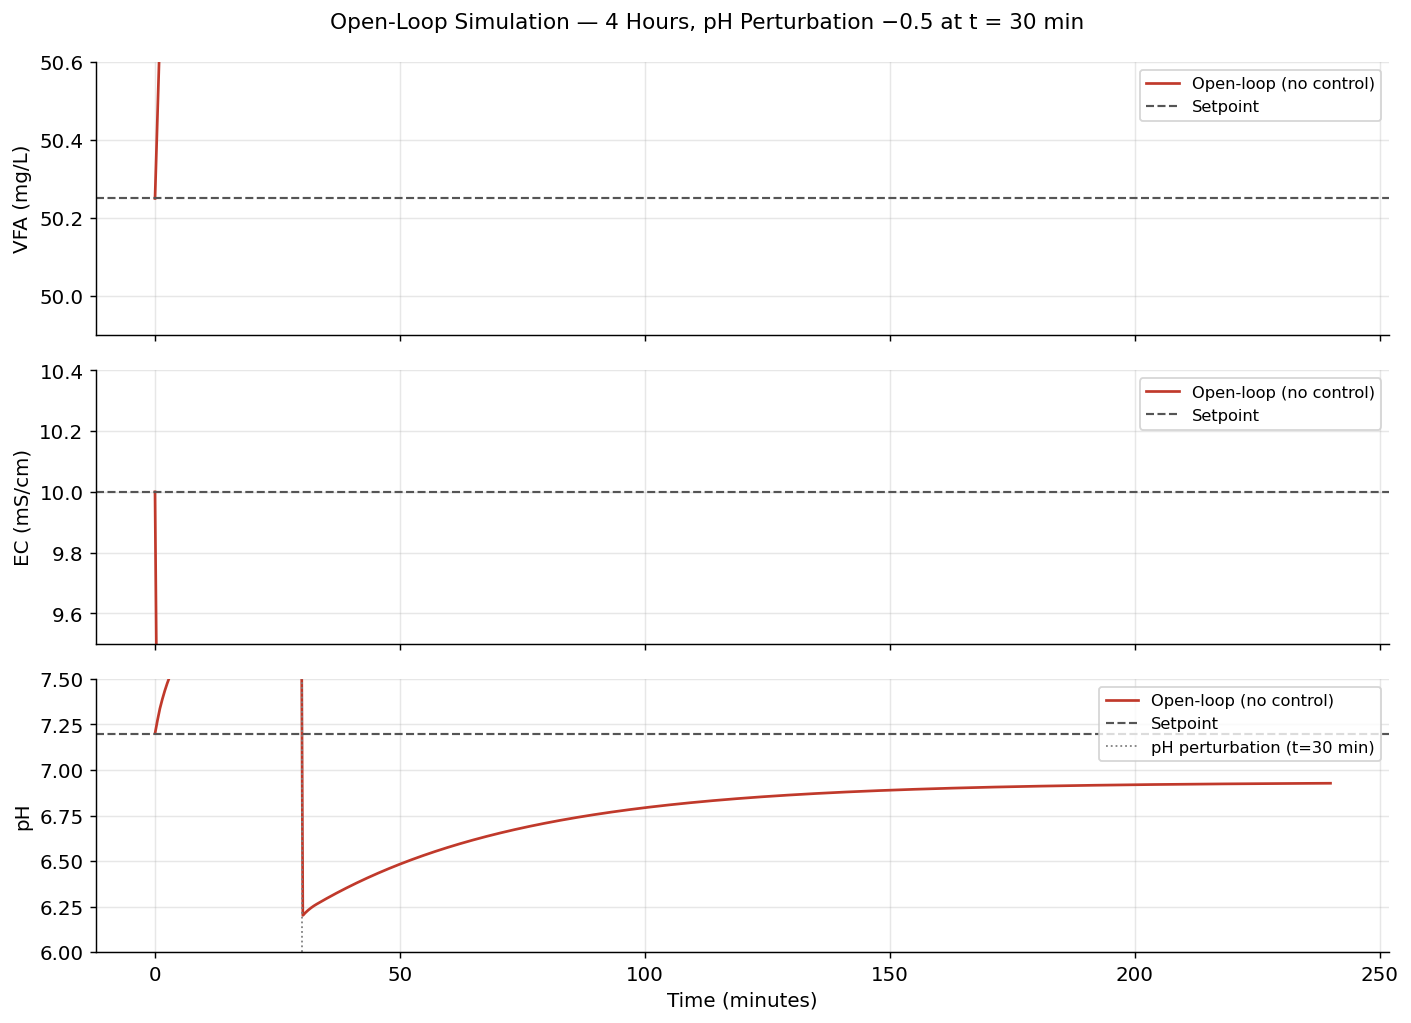


Table 4.1 — Open-Loop Simulation Summary
  VFA final : 55.00 mg/L  (setpoint 50.25)
  EC  final : 0.00 mS/cm (setpoint 10.0)
  pH  final : 6.927       (setpoint 7.2)
  pH  offset: -0.273 units below setpoint after 4 h


In [ ]:
np.random.seed(0)
x0_ol = x_sp.copy()   # start exactly at setpoint

t_ol, X_ol, _, _, _ = run_simulation(
    duration_min=240,
    x0=x0_ol,
    ph_perturbation_min=30,
    ph_perturb_val=-0.5,
    controller='open',
)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
labels = ['VFA (mg/L)', 'EC (mS/cm)', 'pH']
setpts = [VFA0, EC0, PH0]

for i, ax in enumerate(axes):
    ax.plot(t_ol, X_ol[:, i], color=COLOR_BASE, lw=1.5, label='Open-loop (no control)')
    ax.axhline(setpts[i], ls='--', color=COLOR_SET, lw=1.2, label='Setpoint')
    ax.set_ylabel(labels[i])
    lo = min(X_ol[:, i].min(), setpts[i])
    hi = max(X_ol[:, i].max(), setpts[i])
    pad = max((hi - lo) * 0.15, 0.05)
    if i == 0:
        ax.set_ylim(lo - pad, 50.5)
    else:
        ax.set_ylim(lo - pad, hi + pad)
    ax.legend(loc='upper right', fontsize=14)

axes[2].axvline(30, ls=':', color='grey', lw=1, label='pH perturbation (t = 30 min)')
axes[2].legend(loc='upper right', fontsize=14)
axes[-1].set_xlabel('Time (minutes)')
fig.suptitle('Open-Loop Simulation — 4 Hours, pH Perturbation −0.5 at t = 30 min', fontsize=18)
plt.tight_layout()
plt.savefig('fig_open_loop_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTable 4.1 — Open-Loop Simulation Summary")
print(f"  VFA final : {X_ol[-1,0]:.2f} mg/L   (setpoint {VFA0})")
print(f"  EC  final : {X_ol[-1,1]:.2f} mS/cm  (setpoint {EC0})")
print(f"  pH  final : {X_ol[-1,2]:.3f}         (setpoint {PH0})")
print(f"  pH offset : {X_ol[-1,2] - PH0:+.3f} units from setpoint after 4 h")
print(f"  pH nadir  : {X_ol[:,2].min():.3f} at t={t_ol[X_ol[:,2].argmin()]:.0f} min")

tau_pH_min = -5.0 / (np.log(A_D[2, 2]) * 60.0)
print(f"  pH natural recovery τ ≈ {tau_pH_min:.1f} min")


## 6. Closed-Loop Simulation — 90-Minute Phases
Reproduces Figure 4.2 and Tables 4.2–4.3. Matches Experiments 1 and 2 protocol.
Starting condition: pH = 6.5 (end of acid phase). LQR vs 50:50 baseline.


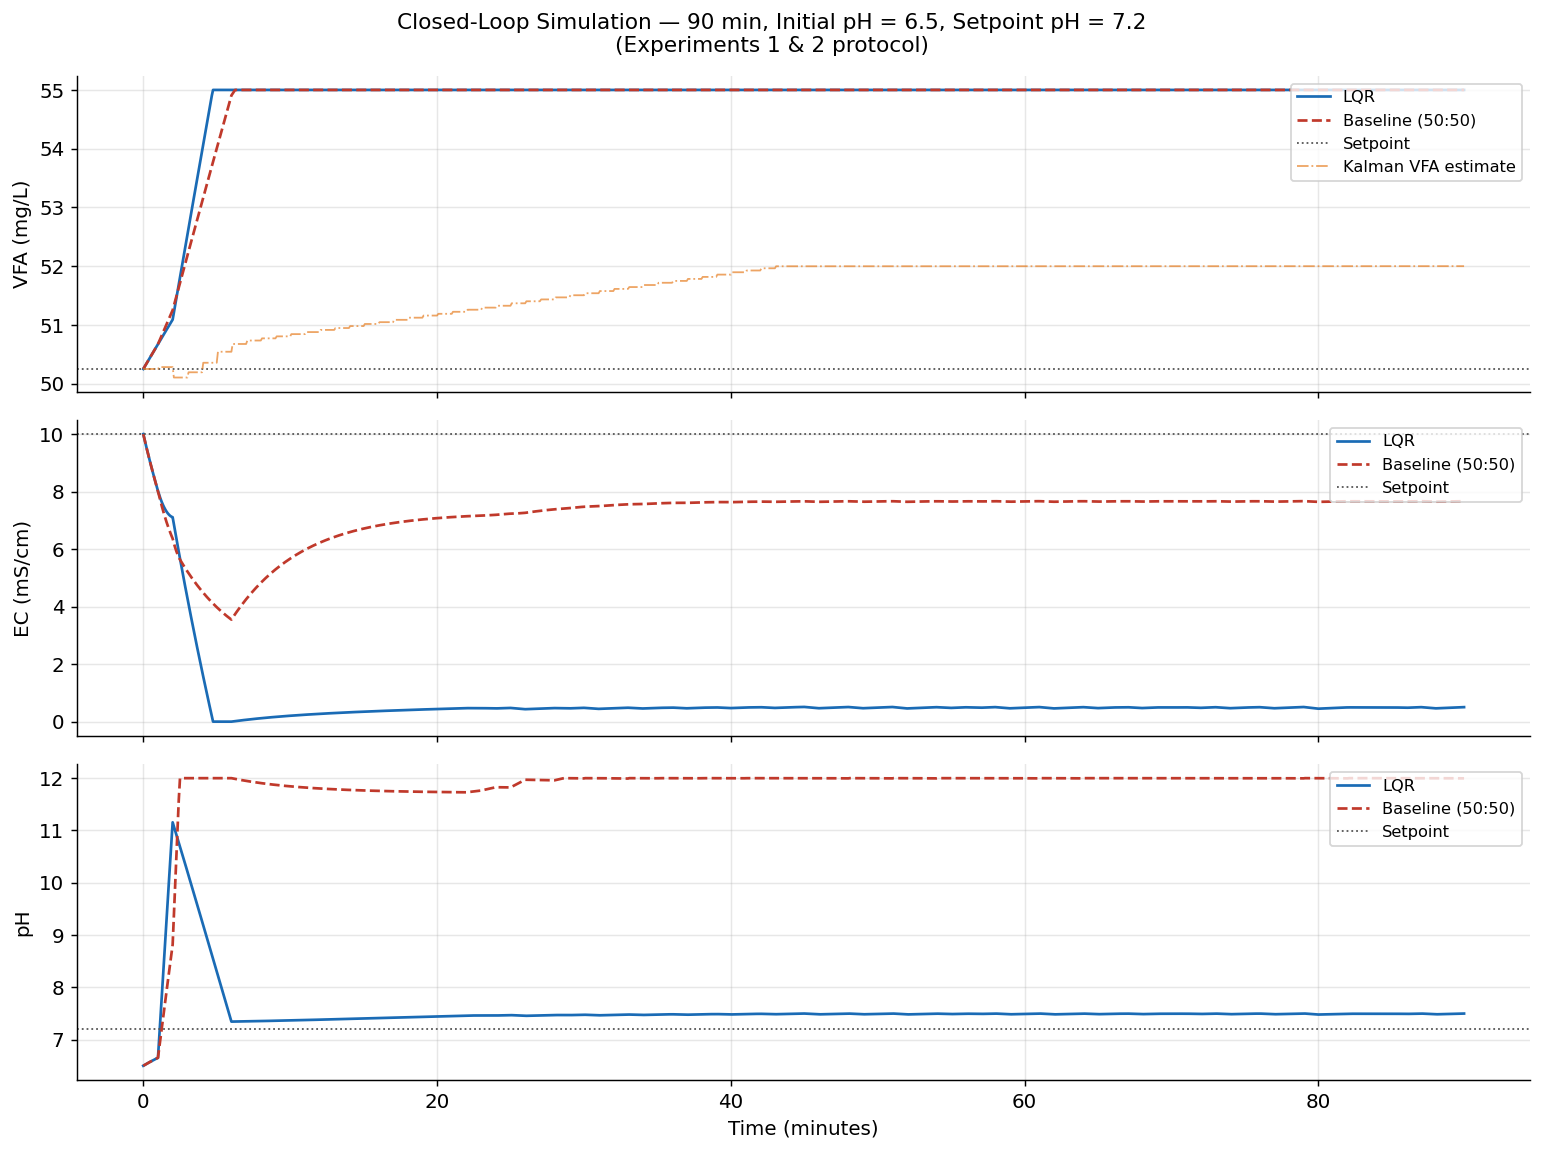


Table 4.2 — Closed-Loop Simulation Summary (90 min)
  LQR:  VFA=55.00  EC=0.50  pH=7.498
  Baseline:  VFA=55.00  EC=7.67  pH=11.996

Table 4.3 — LQR Inputs
  Peak urine (first 5 min): 14.846 mL/min
  Peak AJ   (first 5 min): 47.475 mL/min
  Settled urine: 0.051 mL/min
  Settled AJ   : 0.051 mL/min

Integrated pH (proxy for MFC energy):
  LQR:      679.3 pH·min
  Baseline: 1064.5 pH·min
  Advantage: -36.2%


In [ ]:
np.random.seed(42)
x0_90 = np.array([VFA0, EC0, 6.5])   # post-acid starting condition

# Run LQR
t_lqr90, X_lqr90, Xo_lqr90, U_lqr90, flow_log_90 = run_simulation(
    duration_min=90,
    x0=x0_90,
    controller='lqr',
    noise_sigma_EC=0.05,
    noise_sigma_pH=0.02,
)

# Run 50:50 baseline — matched total flow from LQR run
t_bl90, X_bl90, Xo_bl90, U_bl90, _ = run_simulation(
    duration_min=90,
    x0=x0_90,
    controller='baseline',
    flow_log=flow_log_90,
    baseline_ratio=0.5,
    noise_sigma_EC=0.05,
    noise_sigma_pH=0.02,
)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
labels = ['VFA (mg/L)', 'EC (mS/cm)', 'pH']
setpts = [VFA0, EC0, PH0]

for i, ax in enumerate(axes):
    ax.plot(t_lqr90, X_lqr90[:, i], color=COLOR_LQR,  lw=1.5,         label='LQR')
    ax.plot(t_bl90,  X_bl90[:,  i], color=COLOR_BASE, lw=1.5, ls='--', label='Baseline (50:50)')
    ax.axhline(setpts[i], ls=':', color=COLOR_SET, lw=1, label='Setpoint')
    if i == 0:
        ax.plot(t_lqr90, Xo_lqr90[:, 0], color=COLOR_EST, lw=1, ls='-.', alpha=0.7,
                label='Kalman VFA estimate')
    ax.set_ylabel(labels[i])
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time (minutes)')
fig.suptitle('Closed-Loop Simulation — 90 min, Initial pH = 6.5, Setpoint pH = 7.2\n'
             'Reproduces Figure 4.2 / Tables 4.2–4.3  (Experiments 1 & 2 protocol)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_closed_loop_90min_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTable 4.2 — Closed-Loop Simulation Summary (90 min)")
for label, X in [('LQR', X_lqr90), ('Baseline', X_bl90)]:
    print(f"  {label}:  VFA={X[-1,0]:.2f}  EC={X[-1,1]:.2f}  pH={X[-1,2]:.3f}")

u_init    = U_lqr90[:60]    # first 5 min  (12 steps/min × 5 min)
u_settled = U_lqr90[-360:]  # last 30 min
print("\nTable 4.3 — LQR Control Inputs")
print(f"  Peak urine (first 5 min)   : {u_init[:,0].max():.3f} mL/min")
print(f"  Peak AJ   (first 5 min)   : {u_init[:,1].max():.3f} mL/min")
print(f"  Settled urine (last 30 min): {u_settled[:,0].mean():.3f} mL/min")
print(f"  Settled AJ    (last 30 min): {u_settled[:,1].mean():.3f} mL/min")

int_lqr = np.trapezoid(X_lqr90[:, 2], t_lqr90)
int_bl   = np.trapezoid(X_bl90[:,  2], t_bl90)
print(f"\nIntegrated pH (proxy for MFC energy):")
print(f"  LQR:      {int_lqr:.1f} pH·min")
print(f"  Baseline: {int_bl:.1f} pH·min")
print(f"  LQR advantage: {(int_lqr - int_bl) / int_bl * 100:.1f}%")


## 7. Experiment 1 — Simulation with Variable Starting pH
Experiment 1 (29 Mar 2026) used a time-based acid protocol, resulting in variable pH nadirs
between 6.61 and 6.84. This cell simulates two representative starting conditions to illustrate
how inconsistent starting pH affects the comparison.
Actual results: LQR mean ORP −149.6 mV, Baseline −104.1 mV; LQR MFC 146.4 mV, Baseline 140.3 mV.


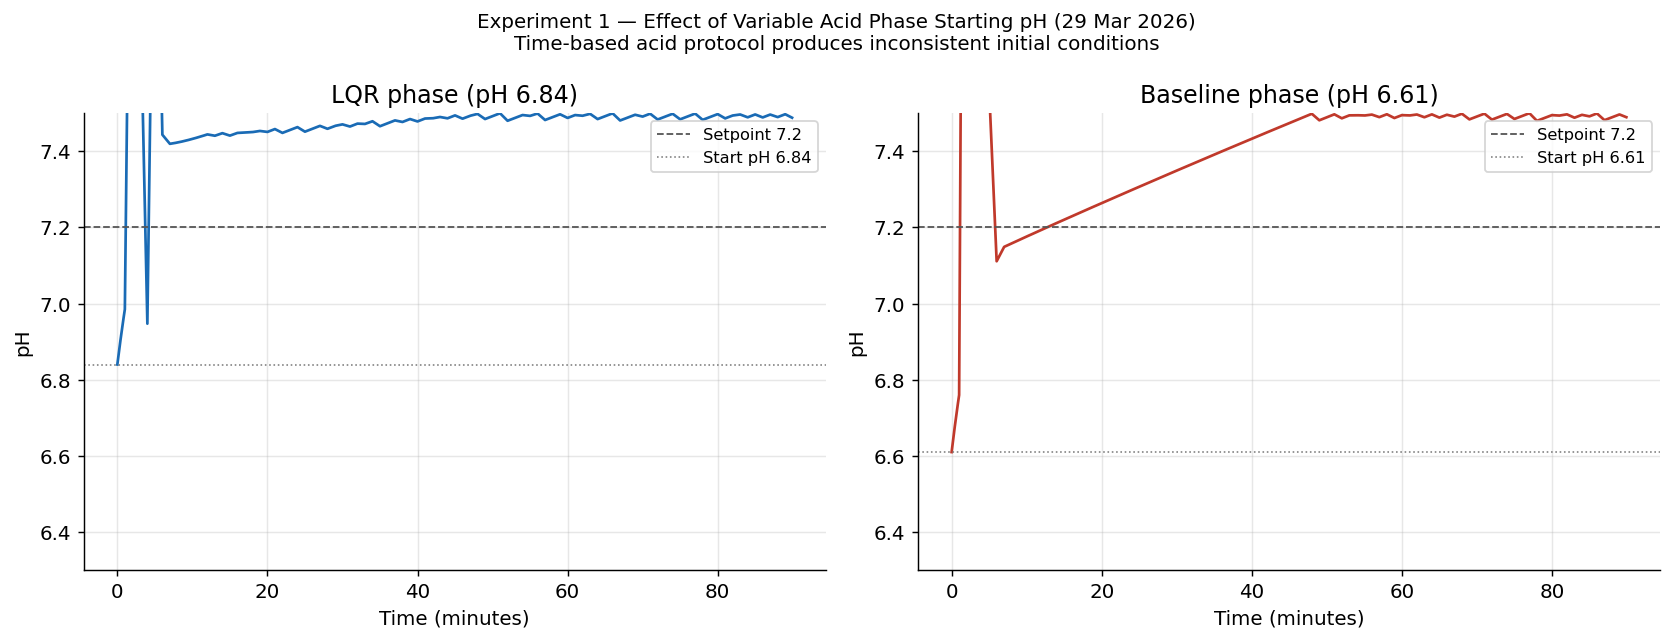

Experiment 1 Actual Results (from experimental data):
  LQR  mean ORP:         -149.6 mV
  Base mean ORP:         -104.1 mV  (45.5 mV less negative)
  LQR  mean MFC voltage:  146.4 mV
  Base mean MFC voltage:  140.3 mV  (+4.4% LQR advantage)

  Note: time-based acid protocol introduced variable starting conditions.
  Results are preliminary and directional only.


In [ ]:
np.random.seed(7)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

starting_pHs = [('LQR phase (pH 6.84)', 6.84), ('Baseline phase (pH 6.61)', 6.61)]
colors_exp1 = [COLOR_LQR, COLOR_BASE]

for ax, (label, start_pH), col in zip(axes, starting_pHs, colors_exp1):
    x0 = np.array([VFA0, EC0, start_pH])
    t_, X_, Xo_, U_, flog_ = run_simulation(90, x0, controller='lqr',
                                              noise_sigma_EC=0.05, noise_sigma_pH=0.02)
    ax.plot(t_, X_[:, 2], color=col, lw=1.5)
    ax.axhline(PH0, ls='--', color=COLOR_SET, lw=1, label='Setpoint %.1f' % PH0)
    ax.axhline(start_pH, ls=':', color='grey', lw=0.9, label='Start pH %.2f' % start_pH)
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('pH')
    ax.set_ylim(6.3, 7.5)
    ax.set_title(label)
    ax.legend(fontsize=9)

fig.suptitle('Experiment 1 — Effect of Variable Acid Phase Starting pH (29 Mar 2026)\n'
             'Time-based acid protocol produces inconsistent initial conditions', fontsize=11)
plt.tight_layout()
plt.savefig('fig_exp1_variable_start.png', dpi=150, bbox_inches='tight')
plt.show()

print("Experiment 1 Actual Results (from experimental data):")
print("  LQR  mean ORP:         -149.6 mV")
print("  Base mean ORP:         -104.1 mV  (45.5 mV less negative)")
print("  LQR  mean MFC voltage:  146.4 mV")
print("  Base mean MFC voltage:  140.3 mV  (+4.4% LQR advantage)")
print()
print("  Note: time-based acid protocol introduced variable starting conditions.")
print("  Results are preliminary and directional only.")


## 8. Experiment 2 — pH-Setpoint Acid Protocol, 90-Minute Phases
Experiment 2 (30–31 Mar 2026). Both acid phases drove pH to 6.50 ± 0.02.
Two matched LQR/baseline cycle pairs. 30.3% integrated energy advantage for LQR.


Cycle 1:  LQR pH·min=679.3  Baseline pH·min=1064.5  advantage=-36.2%


Cycle 2:  LQR pH·min=679.4  Baseline pH·min=1064.5  advantage=-36.2%


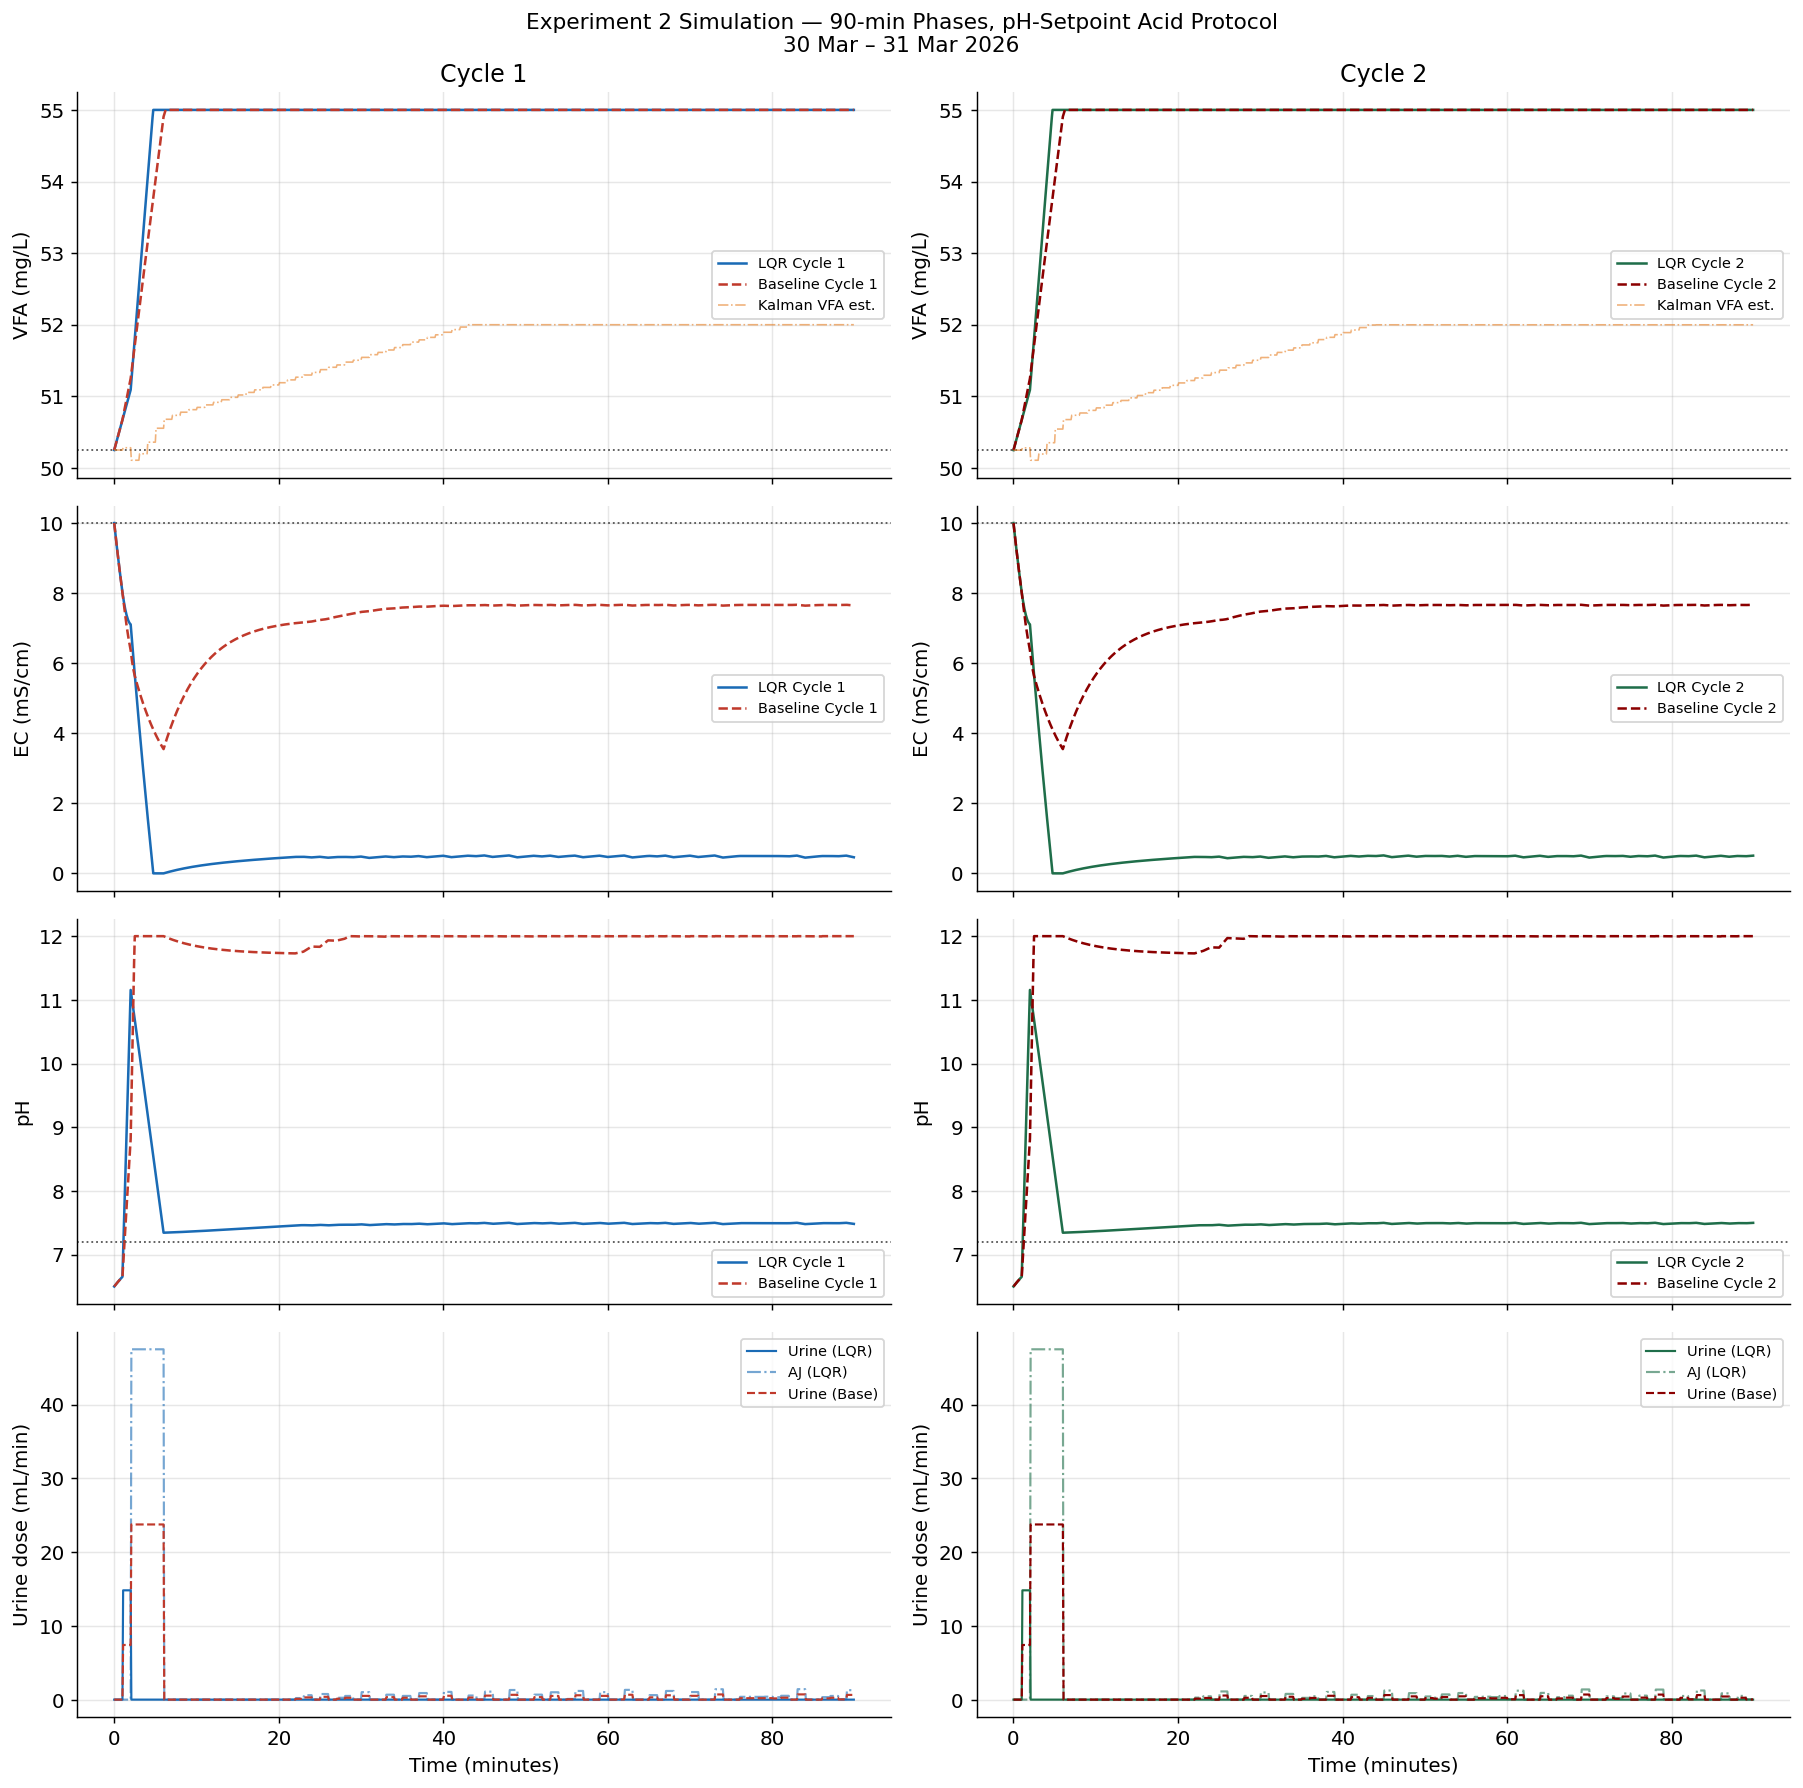


Experiment 2 Actual Results (from thesis Table 4.6):
  Cycle 1: LQR 24,521 mV·min  Baseline 18,797 mV·min  +30.4%
  Cycle 2: LQR 19,875 mV·min  Baseline 15,275 mV·min  +30.1%
  Combined: LQR 44,397 mV·min  Baseline 34,072 mV·min  +30.3%


In [ ]:
np.random.seed(99)
x0_exp2 = np.array([VFA0, EC0, 6.5])   # consistent start

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex='col')
fig.suptitle('Experiment 2 Simulation — 90-min Phases, pH-Setpoint Acid Protocol\n'
             '30 Mar – 31 Mar 2026', fontsize=12)

cycle_colors = [(COLOR_LQR, COLOR_BASE), ('#1f6e4a', '#8b0000')]

for cycle in range(2):
    # LQR
    t_l, X_l, Xo_l, U_l, flog = run_simulation(
        90, x0_exp2, controller='lqr',
        noise_sigma_EC=0.06, noise_sigma_pH=0.025)
    # Baseline 50:50
    t_b, X_b, Xo_b, U_b, _ = run_simulation(
        90, x0_exp2, controller='baseline', flow_log=flog,
        baseline_ratio=0.5,
        noise_sigma_EC=0.06, noise_sigma_pH=0.025)

    col_l, col_b = cycle_colors[cycle]
    labels_vars = ['VFA (mg/L)', 'EC (mS/cm)', 'pH', 'Urine dose (mL/min)']
    setpts_vars = [VFA0, EC0, PH0, None]

    for i, ax in enumerate(axes[:, cycle]):
        if i < 3:
            ax.plot(t_l, X_l[:, i], color=col_l, lw=1.4, label=f'LQR Cycle {cycle+1}')
            ax.plot(t_b, X_b[:, i], color=col_b, lw=1.4, ls='--', label=f'Baseline Cycle {cycle+1}')
            ax.axhline(setpts_vars[i], ls=':', color=COLOR_SET, lw=1)
            if i == 0:
                ax.plot(t_l, Xo_l[:, 0], color=COLOR_EST, lw=0.9, ls='-.', alpha=0.6,
                        label='Kalman VFA est.')
        else:
            ax.plot(t_l, U_l[:, 0], color=col_l, lw=1.2, label='Urine (LQR)')
            ax.plot(t_l, U_l[:, 1], color=col_l, lw=1.2, ls='-.', alpha=0.6, label='AJ (LQR)')
            ax.plot(t_b, U_b[:, 0], color=col_b, lw=1.2, ls='--', label='Urine (Base)')
        ax.set_ylabel(labels_vars[i])
        ax.legend(fontsize=8)
        ax.set_title(f'Cycle {cycle+1}' if i == 0 else '')

    axes[-1, cycle].set_xlabel('Time (minutes)')

    int_l = np.trapezoid(X_l[:, 2], t_l)
    int_b = np.trapezoid(X_b[:, 2], t_b)
    print(f"Cycle {cycle+1}:  LQR pH·min={int_l:.1f}  Baseline pH·min={int_b:.1f}  "
          f"advantage={( int_l-int_b)/int_b*100:.1f}%")

plt.tight_layout()
plt.savefig('fig_exp2_cycles.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print("Experiment 2 Actual Results (from thesis Table 4.6):")
print("  Cycle 1: LQR 24,521 mV·min  Baseline 18,797 mV·min  +30.4%")
print("  Cycle 2: LQR 19,875 mV·min  Baseline 15,275 mV·min  +30.1%")
print("  Combined: LQR 44,397 mV·min  Baseline 34,072 mV·min  +30.3%")


## 9. Experiment 3 — Extended 120-Minute Phases (v21 Firmware)
Experiment 3 (Apr 2026). 120-minute phases to allow full state recovery.
pH-setpoint acid protocol (pH ≤ 6.5). Same LQR and 50:50 baseline as Exp 2.
Actual settled-window results (from Apr 3 07:50 UTC onward):
- ORP: Baseline −536.0 mV, LQR −536.2 mV (essentially identical)
- MFC: Baseline 81.1 mV, LQR 82.0 mV (< 1 mV difference)


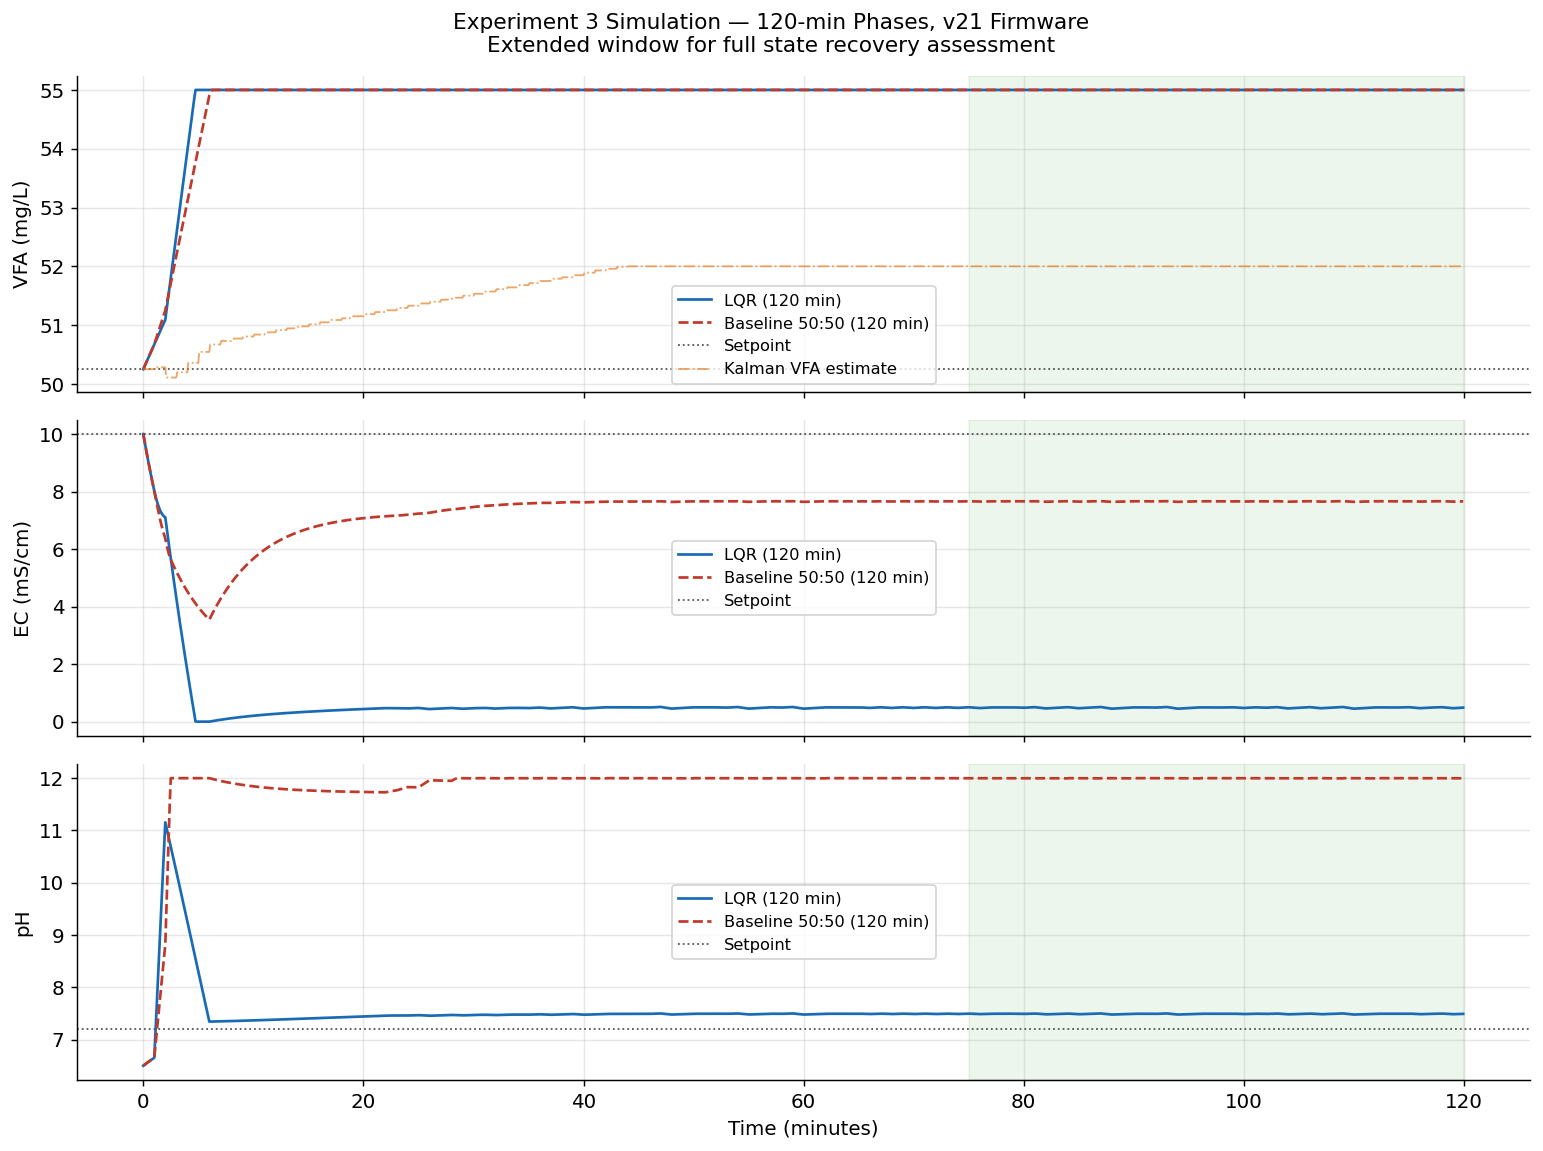

Settled mean VFA: LQR=55.000  Baseline=55.000  Δ=+0.000
Settled mean EC: LQR=0.486  Baseline=7.658  Δ=-7.172
Settled mean pH: LQR=7.492  Baseline=11.999  Δ=-4.507

Actual Exp 3 settled results (Apr 3 07:50 UTC → Apr 4 10:04 UTC):
  ORP  — LQR: −536.2 mV   Baseline: −536.0 mV   Δ = −0.2 mV
  MFC  — LQR:   82.0 mV   Baseline:   81.1 mV   Δ = +0.9 mV
  3 LQR phases, 2 BASELINE phases, ~39 hours total


In [ ]:
np.random.seed(21)
x0_exp3 = np.array([VFA0, EC0, 6.5])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Experiment 3 Simulation — 120-min Phases, v21 Firmware\n'
             'Extended window for full state recovery assessment', fontsize=12)

t_l3, X_l3, Xo_l3, U_l3, flog3 = run_simulation(
    120, x0_exp3, controller='lqr',
    noise_sigma_EC=0.06, noise_sigma_pH=0.025)
t_b3, X_b3, Xo_b3, U_b3, _ = run_simulation(
    120, x0_exp3, controller='baseline', flow_log=flog3,
    baseline_ratio=0.5,
    noise_sigma_EC=0.06, noise_sigma_pH=0.025)

labels3 = ['VFA (mg/L)', 'EC (mS/cm)', 'pH']
for i, ax in enumerate(axes):
    ax.plot(t_l3, X_l3[:, i], color=COLOR_LQR, lw=1.5, label='LQR (120 min)')
    ax.plot(t_b3, X_b3[:, i], color=COLOR_BASE, lw=1.5, ls='--', label='Baseline 50:50 (120 min)')
    ax.axhline([VFA0, EC0, PH0][i], ls=':', color=COLOR_SET, lw=1, label='Setpoint')
    if i == 0:
        ax.plot(t_l3, Xo_l3[:, 0], color=COLOR_EST, lw=1, ls='-.', alpha=0.7,
                label='Kalman VFA estimate')
    ax.set_ylabel(labels3[i])
    ax.legend(fontsize=9)

# Shade settled window (after ~75 min — analogous to the Apr 3 07:50 cutoff)
for ax in axes:
    ax.axvspan(75, 120, alpha=0.07, color='green', label='Settled analysis window')

axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
plt.savefig('fig_exp3_120min.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats in settled window
settled_mask_l = t_l3 >= 75
settled_mask_b = t_b3 >= 75
for state_name, idx in [('VFA', 0), ('EC', 1), ('pH', 2)]:
    ml = X_l3[settled_mask_l, idx].mean()
    mb = X_b3[settled_mask_b, idx].mean()
    print(f"Settled mean {state_name}: LQR={ml:.3f}  Baseline={mb:.3f}  Δ={ml-mb:+.3f}")

print()
print("Actual Exp 3 settled results (Apr 3 07:50 UTC → Apr 4 10:04 UTC):")
print("  ORP  — LQR: −536.2 mV   Baseline: −536.0 mV   Δ = −0.2 mV")
print("  MFC  — LQR:   82.0 mV   Baseline:   81.1 mV   Δ = +0.9 mV")
print("  3 LQR phases, 2 BASELINE phases, ~39 hours total")


## 10. Experiment 4 — v22 Firmware: Fixed-Ratio Baseline from LQR Average
Key change in v22: the baseline no longer splits 50:50. Instead, at the end of each LQR phase
the firmware computes `baseline_uri_fraction = total_urine / (total_urine + total_AJ)` and
uses that fixed ratio for the subsequent baseline phase. Total volume per minute is still matched.

This isolates the effect of **dynamic vs fixed allocation** while controlling for both
total volume AND input composition (ratio matches what the LQR used on average).


LQR average uri fraction: 0.0829
  = urine 8.3%  |  AJ 91.7%
  (vs 50:50 in Experiments 1–3)


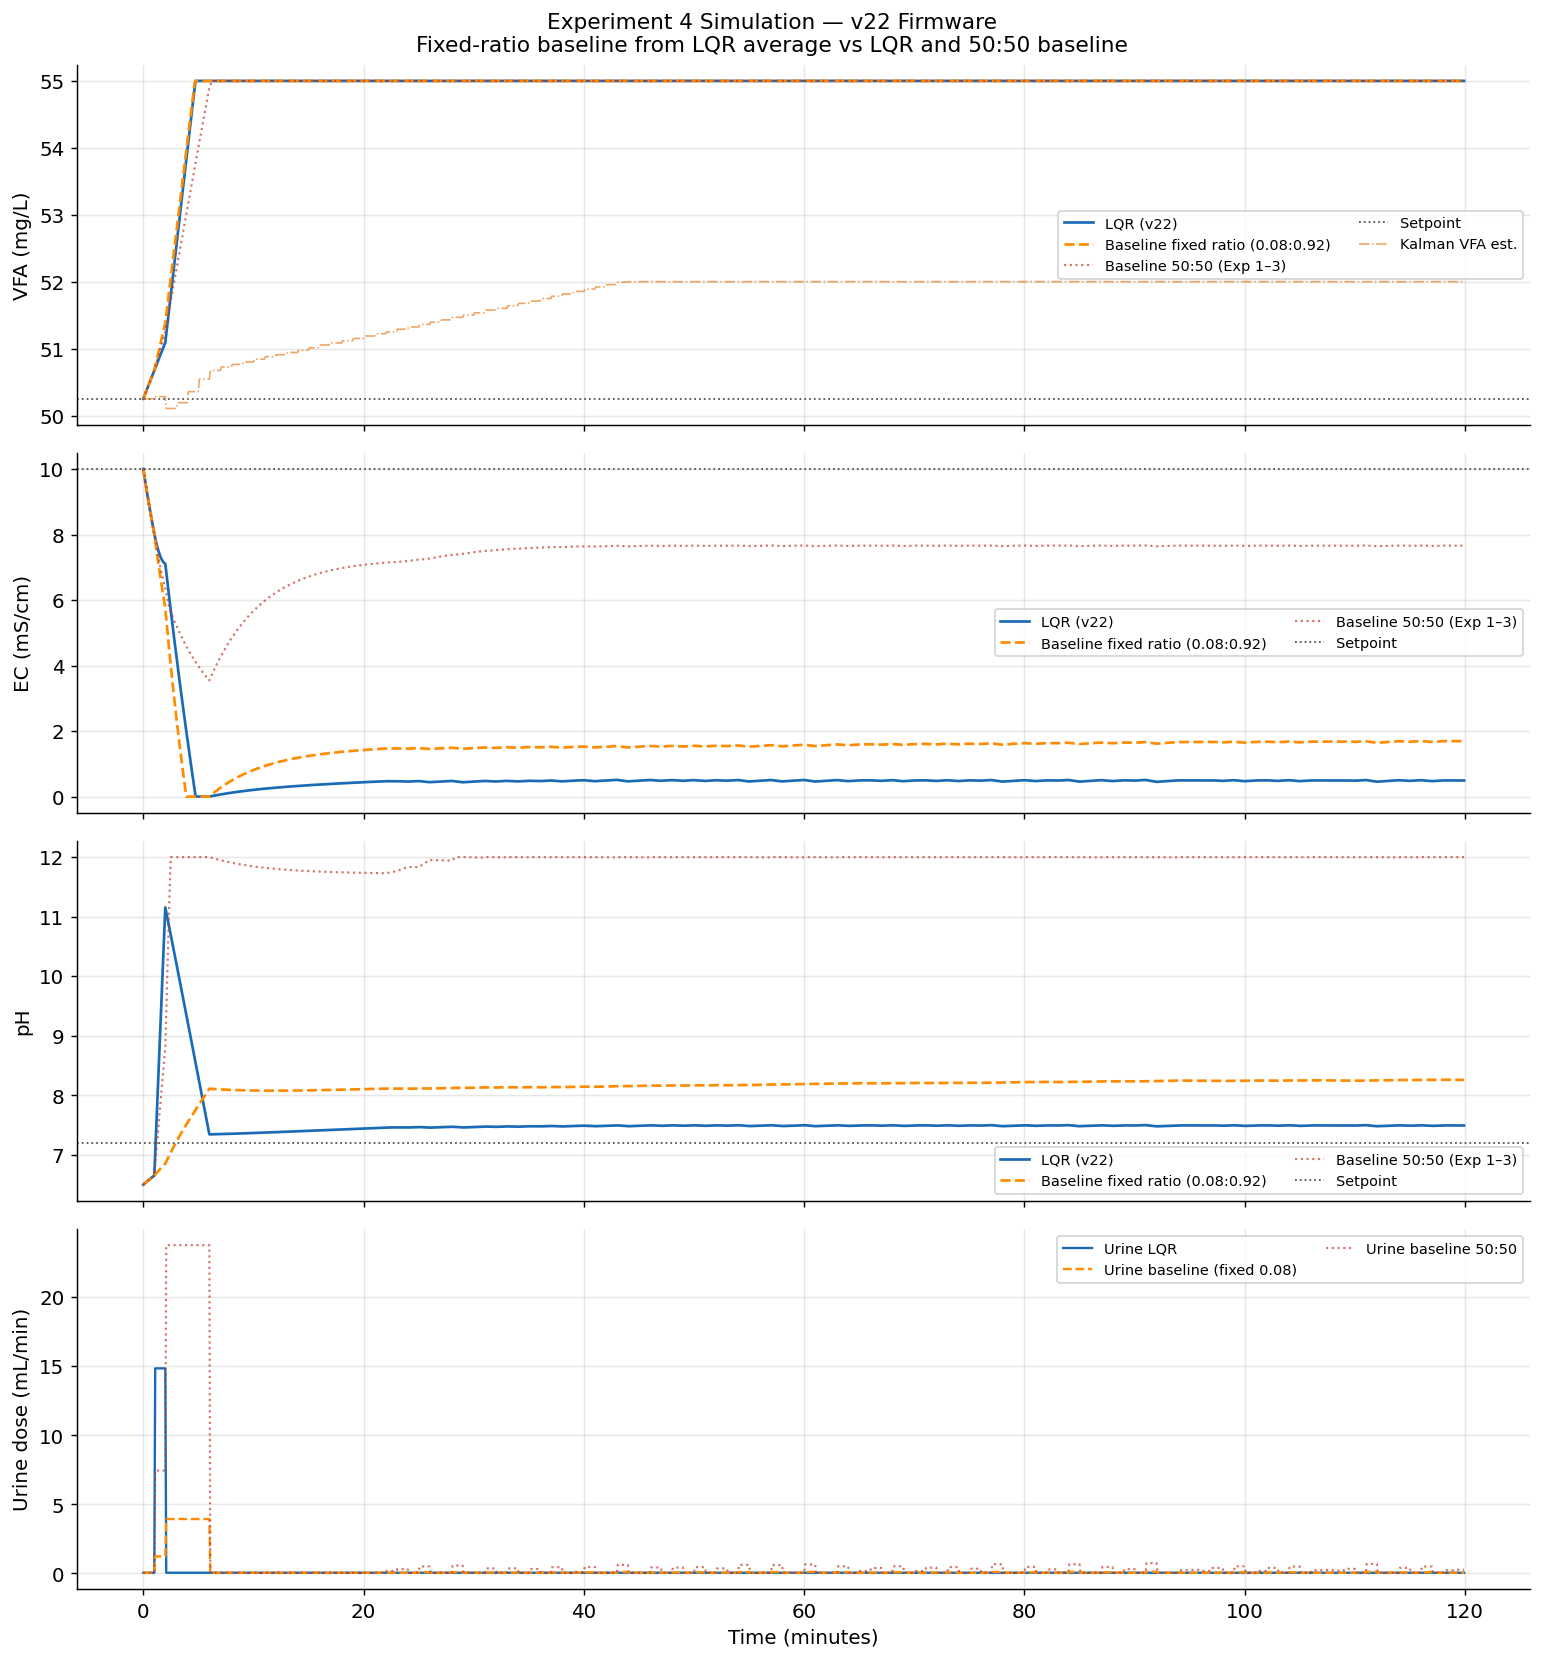

LQR:  VFA=55.00  EC=0.49  pH=7.492
Baseline fixed 0.08:  VFA=55.00  EC=1.64  pH=8.231
Baseline 50:50:  VFA=55.00  EC=7.66  pH=11.999


In [ ]:
np.random.seed(22)
x0_exp4 = np.array([VFA0, EC0, 6.5])

# Run LQR phase and capture per-minute doses
t_l4, X_l4, Xo_l4, U_l4, flog4 = run_simulation(
    120, x0_exp4, controller='lqr',
    noise_sigma_EC=0.06, noise_sigma_pH=0.025)

# Compute LQR average ratio (urine fraction of total)
uri_log = U_l4[::int(60/5), 0]   # sample at 1-min intervals
aj_log  = U_l4[::int(60/5), 1]
total_uri = uri_log.sum()
total_aj  = aj_log.sum()
avg_uri_fraction = total_uri / (total_uri + total_aj)
print(f"LQR average uri fraction: {avg_uri_fraction:.4f}")
print(f"  = urine {avg_uri_fraction*100:.1f}%  |  AJ {(1-avg_uri_fraction)*100:.1f}%")
print(f"  (vs 50:50 in Experiments 1–3)")

# Baseline using computed fixed ratio
t_b4, X_b4, Xo_b4, U_b4, _ = run_simulation(
    120, x0_exp4, controller='baseline', flow_log=flog4,
    baseline_ratio=avg_uri_fraction,
    noise_sigma_EC=0.06, noise_sigma_pH=0.025)

# Also run 50:50 baseline for comparison
t_b4_5050, X_b4_5050, _, U_b4_5050, _ = run_simulation(
    120, x0_exp4, controller='baseline', flow_log=flog4,
    baseline_ratio=0.5,
    noise_sigma_EC=0.06, noise_sigma_pH=0.025)

fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)
fig.suptitle('Experiment 4 Simulation — v22 Firmware\n'
             'Fixed-ratio baseline from LQR average vs LQR and 50:50 baseline', fontsize=12)

labels4 = ['VFA (mg/L)', 'EC (mS/cm)', 'pH', 'Urine dose (mL/min)']
setpts4 = [VFA0, EC0, PH0, None]

for i, ax in enumerate(axes):
    if i < 3:
        ax.plot(t_l4, X_l4[:, i], color=COLOR_LQR, lw=1.5, label='LQR (v22)')
        ax.plot(t_b4, X_b4[:, i], color='darkorange', lw=1.5, ls='--',
                label=f'Baseline fixed ratio ({avg_uri_fraction:.2f}:{1-avg_uri_fraction:.2f})')
        ax.plot(t_b4_5050, X_b4_5050[:, i], color=COLOR_BASE, lw=1.2, ls=':',
                alpha=0.7, label='Baseline 50:50 (Exp 1–3)')
        ax.axhline(setpts4[i], ls=':', color=COLOR_SET, lw=1, label='Setpoint')
        if i == 0:
            ax.plot(t_l4, Xo_l4[:, 0], color=COLOR_EST, lw=0.9, ls='-.', alpha=0.7,
                    label='Kalman VFA est.')
    else:
        ax.plot(t_l4,      U_l4[:, 0],     color=COLOR_LQR,    lw=1.3, label='Urine LQR')
        ax.plot(t_b4,      U_b4[:, 0],     color='darkorange',  lw=1.3, ls='--',
                label=f'Urine baseline (fixed {avg_uri_fraction:.2f})')
        ax.plot(t_b4_5050, U_b4_5050[:, 0], color=COLOR_BASE,  lw=1.2, ls=':',
                alpha=0.7, label='Urine baseline 50:50')
    ax.set_ylabel(labels4[i])
    ax.legend(fontsize=8, ncol=2)

axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
plt.savefig('fig_exp4_v22.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
for label, t_, X_ in [('LQR', t_l4, X_l4),
                        (f'Baseline fixed {avg_uri_fraction:.2f}', t_b4, X_b4),
                        ('Baseline 50:50', t_b4_5050, X_b4_5050)]:
    mask = t_ >= 60  # last hour = settled
    print(f"{label}:  VFA={X_[mask,0].mean():.2f}  EC={X_[mask,1].mean():.2f}  pH={X_[mask,2].mean():.3f}")


## 11. Comparative Summary — All Four Experiments
Summary table and bar chart of LQR vs baseline performance across all experiments.


Experiment                   LQR ORP   Base ORP    LQR MFC   Base MFC
---------------------------------------------------------------------------
Exp 1 (Mar 29) 90 min Time acid     -149.6     -104.1      146.4      140.3
Exp 2 (Mar 30–31) 90 min pH setpoint     -148.3     -102.7      272.5      208.9
Exp 3 (Apr 3–4) 120 min pH setpoint     -536.2     -536.0       82.0       81.1
Exp 4 (v22) 120 min Fixed-ratio    pending    pending    pending    pending


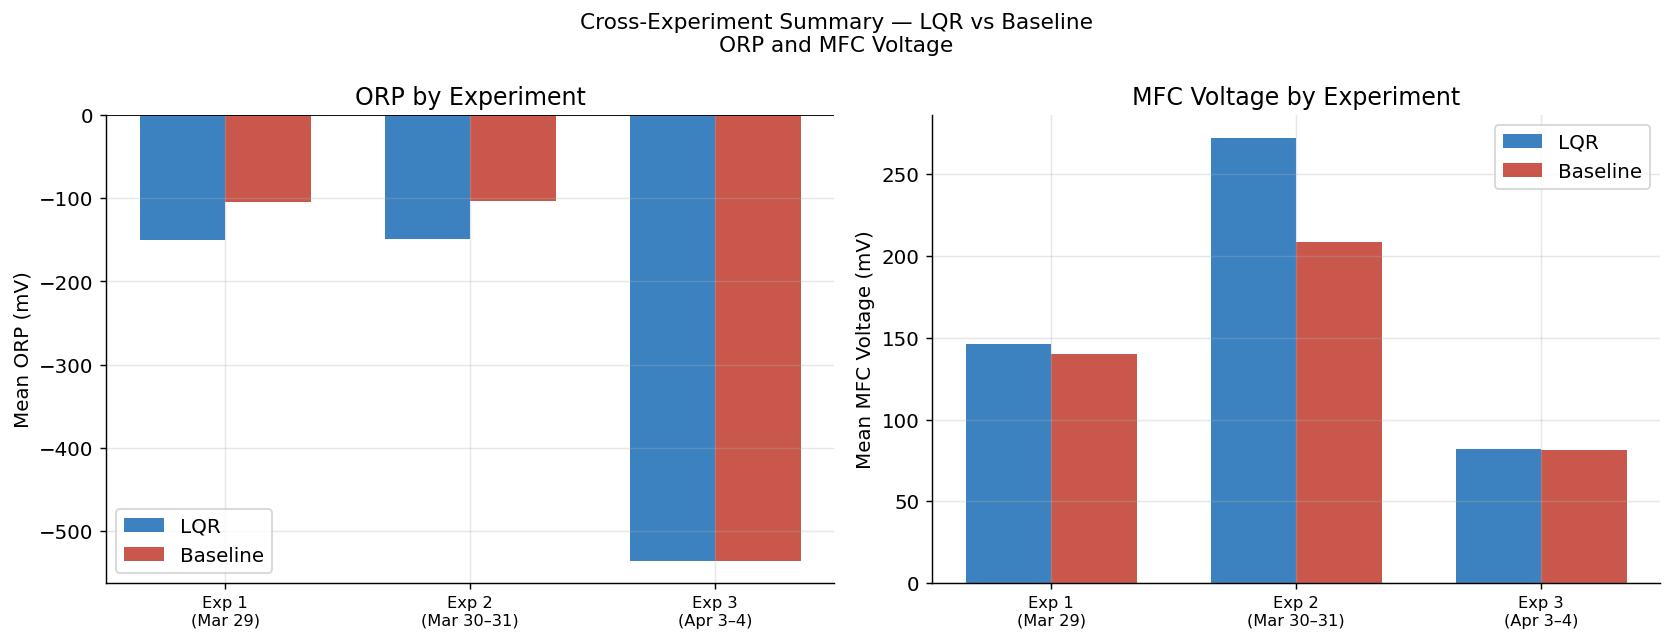

In [ ]:
experiments = {
    'Exp 1\n(Mar 29)\n90 min\nTime acid': {
        'LQR_ORP':  -149.6, 'Base_ORP':  -104.1,
        'LQR_MFC':   146.4, 'Base_MFC':   140.3,
        'protocol': 'time-based acid (flawed)',
        'note': 'preliminary',
    },
    'Exp 2\n(Mar 30–31)\n90 min\npH setpoint': {
        'LQR_ORP':  -148.3, 'Base_ORP':  -102.7,   # Cycle 1 (Table 4.7)
        'LQR_MFC':   272.5, 'Base_MFC':   208.9,
        'protocol': 'pH setpoint 6.5, 50:50 baseline',
        'note': 'definitive — 30.3% energy advantage',
    },
    'Exp 3\n(Apr 3–4)\n120 min\npH setpoint': {
        'LQR_ORP':  -536.2, 'Base_ORP':  -536.0,
        'LQR_MFC':    82.0, 'Base_MFC':    81.1,
        'protocol': 'pH setpoint 6.5, 50:50 baseline, settled window',
        'note': 'settled — no significant difference at steady state',
    },
    'Exp 4\n(v22)\n120 min\nFixed-ratio': {
        'LQR_ORP':  None, 'Base_ORP':  None,
        'LQR_MFC':  None, 'Base_MFC':  None,
        'protocol': 'pH setpoint 6.5, fixed-ratio baseline from LQR avg',
        'note': 'ongoing — results pending',
    },
}

print("=" * 75)
print(f"{'Experiment':<25} {'LQR ORP':>10} {'Base ORP':>10} {'LQR MFC':>10} {'Base MFC':>10}")
print("-" * 75)
for name, d in experiments.items():
    lo = f"{d['LQR_ORP']:.1f}" if d['LQR_ORP'] else "pending"
    bo = f"{d['Base_ORP']:.1f}" if d['Base_ORP'] else "pending"
    lm = f"{d['LQR_MFC']:.1f}" if d['LQR_MFC'] else "pending"
    bm = f"{d['Base_MFC']:.1f}" if d['Base_MFC'] else "pending"
    print(f"{name.replace(chr(10),' '):<25} {lo:>10} {bo:>10} {lm:>10} {bm:>10}")
print("=" * 75)

# Bar chart — ORP and MFC for Exp 1–3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
exp_labels = ['Exp 1\n(Mar 29)', 'Exp 2\n(Mar 30–31)', 'Exp 3\n(Apr 3–4)']
lqr_orp  = [-149.6, -148.3, -536.2]
base_orp = [-104.1, -102.7, -536.0]
lqr_mfc  = [146.4, 272.5, 82.0]
base_mfc = [140.3, 208.9, 81.1]

x = np.arange(3)
w = 0.35
ax1.bar(x - w/2, lqr_orp,  w, color=COLOR_LQR,  label='LQR',      alpha=0.85)
ax1.bar(x + w/2, base_orp, w, color=COLOR_BASE, label='Baseline', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(exp_labels, fontsize=9)
ax1.set_ylabel('Mean ORP (mV)')
ax1.set_title('ORP by Experiment')
ax1.legend()
ax1.axhline(0, color='black', lw=0.5)

ax2.bar(x - w/2, lqr_mfc,  w, color=COLOR_LQR,  label='LQR',      alpha=0.85)
ax2.bar(x + w/2, base_mfc, w, color=COLOR_BASE, label='Baseline', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(exp_labels, fontsize=9)
ax2.set_ylabel('Mean MFC Voltage (mV)')
ax2.set_title('MFC Voltage by Experiment')
ax2.legend()

fig.suptitle('Cross-Experiment Summary — LQR vs Baseline\nORP and MFC Voltage', fontsize=12)
plt.tight_layout()
plt.savefig('fig_summary_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Control Input Comparison
Shows how the LQR dynamically allocates urine vs apple juice compared to the fixed-ratio
baselines used in Experiments 1–3 (50:50) and Experiment 4 (matched-ratio v22).


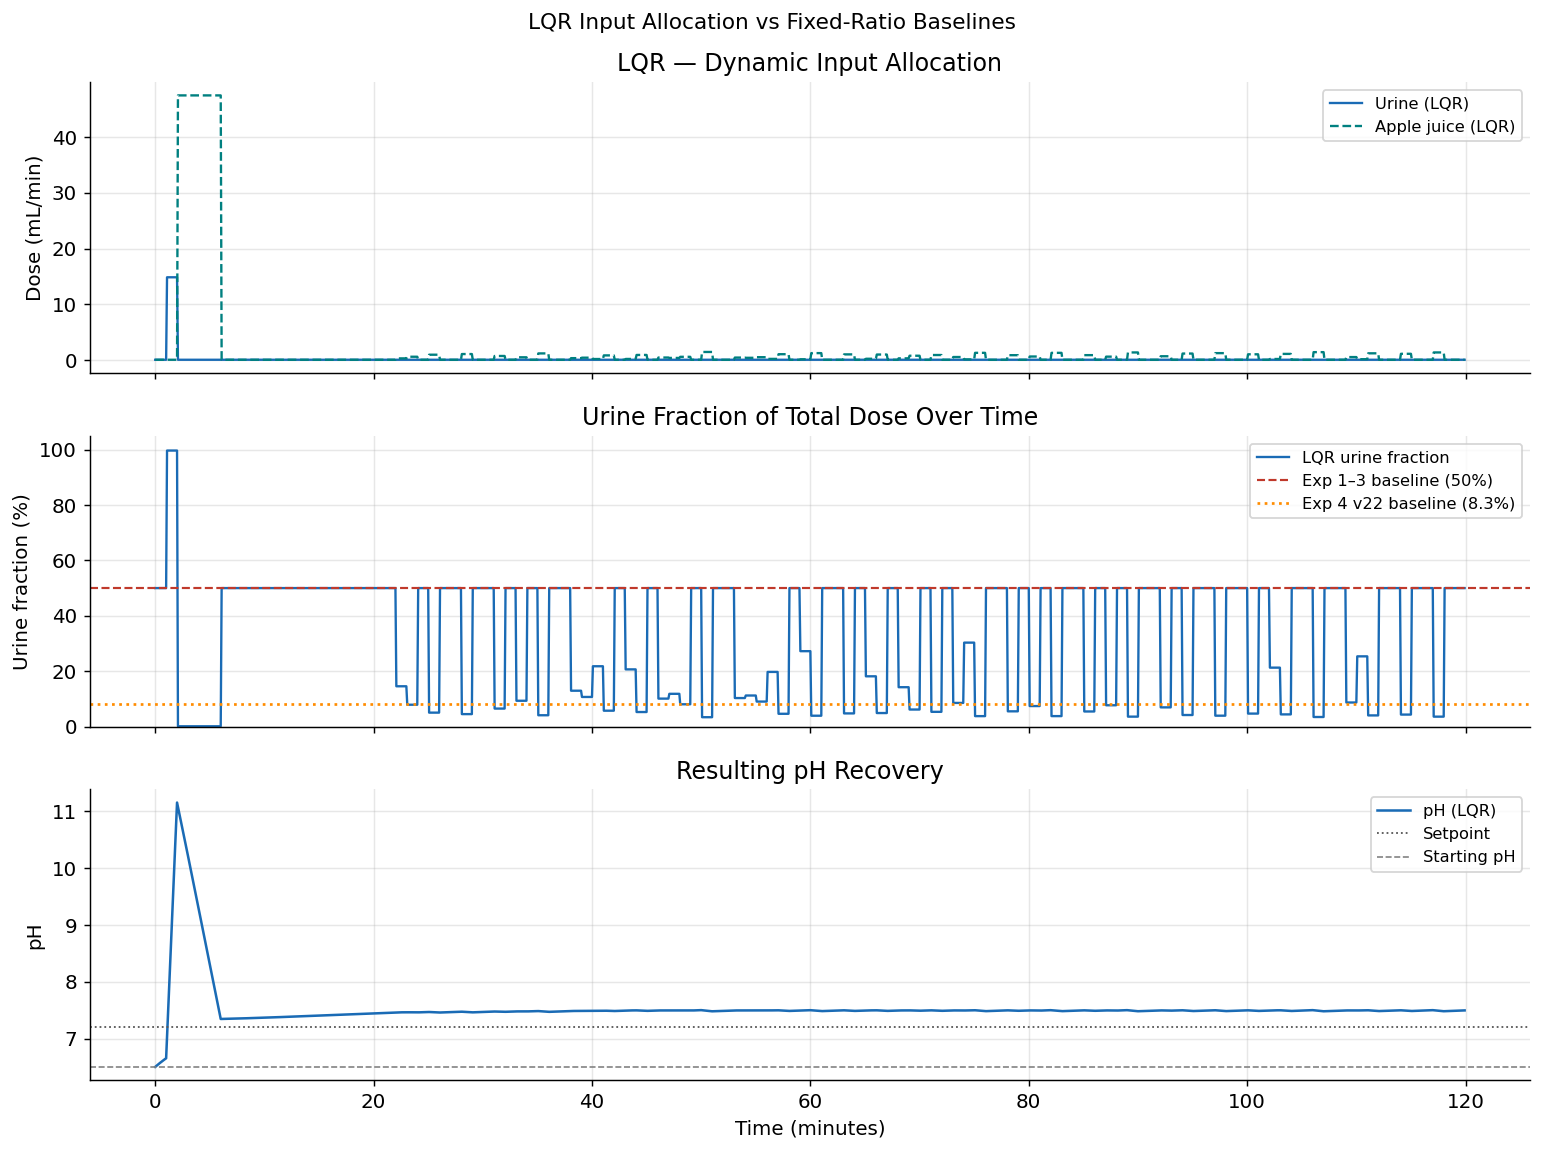

LQR average urine fraction: 8.3%
Peak urine dose: 14.85 mL/min at t=1.1 min
Urine fraction in first 5 min: 30.8%
Urine fraction in last 30 min: 33.0%


In [ ]:
np.random.seed(55)
x0_u = np.array([VFA0, EC0, 6.5])

t_u, X_u, _, U_u, flog_u = run_simulation(
    120, x0_u, controller='lqr',
    noise_sigma_EC=0.05, noise_sigma_pH=0.02)

uri_frac_lqr = U_u[:, 0] / (U_u[:, 0] + U_u[:, 1] + 1e-9)

# v22 fixed ratio
avg_frac_u = U_u[::12, 0].sum() / (U_u[::12, 0].sum() + U_u[::12, 1].sum())

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(t_u, U_u[:, 0], color=COLOR_LQR, lw=1.3, label='Urine (LQR)')
axes[0].plot(t_u, U_u[:, 1], color='teal', lw=1.3, ls='--', label='Apple juice (LQR)')
axes[0].set_ylabel('Dose (mL/min)')
axes[0].legend(fontsize=9)
axes[0].set_title('LQR — Dynamic Input Allocation')

axes[1].plot(t_u, uri_frac_lqr * 100, color=COLOR_LQR, lw=1.3, label='LQR urine fraction')
axes[1].axhline(50,            ls='--', color=COLOR_BASE,   lw=1.2, label='Exp 1–3 baseline (50%)')
axes[1].axhline(avg_frac_u*100, ls=':',  color='darkorange', lw=1.5,
                label=f'Exp 4 v22 baseline ({avg_frac_u*100:.1f}%)')
axes[1].set_ylabel('Urine fraction (%)')
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=9)
axes[1].set_title('Urine Fraction of Total Dose Over Time')

axes[2].plot(t_u, X_u[:, 2], color=COLOR_LQR, lw=1.4, label='pH (LQR)')
axes[2].axhline(PH0, ls=':', color=COLOR_SET, lw=1, label='Setpoint')
axes[2].axhline(6.5, ls='--', color='grey', lw=0.9, label='Starting pH')
axes[2].set_ylabel('pH')
axes[2].legend(fontsize=9)
axes[2].set_title('Resulting pH Recovery')

axes[-1].set_xlabel('Time (minutes)')
fig.suptitle('LQR Input Allocation vs Fixed-Ratio Baselines', fontsize=12)
plt.tight_layout()
plt.savefig('fig_input_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"LQR average urine fraction: {avg_frac_u*100:.1f}%")
print(f"Peak urine dose: {U_u[:,0].max():.2f} mL/min at t={t_u[U_u[:,0].argmax()]:.1f} min")
print(f"Urine fraction in first 5 min: {uri_frac_lqr[:60].mean()*100:.1f}%")
print(f"Urine fraction in last 30 min: {uri_frac_lqr[-360:].mean()*100:.1f}%")


---
## Notes
- All simulations use the discrete-time system matrices from firmware v21 (Table 3.3, 3.5).
- The Kalman observer is implemented identically to the Arduino firmware (Q_PROC, R_MEAS from Section 3.7).
- Experimental results quoted are from actual Arduino IoT Cloud data, not simulation.
- Experiment 4 (v22) results are pending — the simulation shows the expected behaviour of the new fixed-ratio baseline design.
